In [951]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from skimage import util, filters, io, transform, img_as_float
from skimage.restoration import inpaint_biharmonic
from skimage.feature import match_template, peak_local_max

from matplotlib import cm

from stm_voronoi_mst import img_file, gray_process, voronoi_tree, graph_from_peaks, statistics

In [952]:
# =====================
# PARAMETERS
# =====================
f = r"sample_scale_53.png"

dsize = 11

C:\Users\Matth\AppData\Local\Temp\ipykernel_10696\1147900446.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('afmhot')


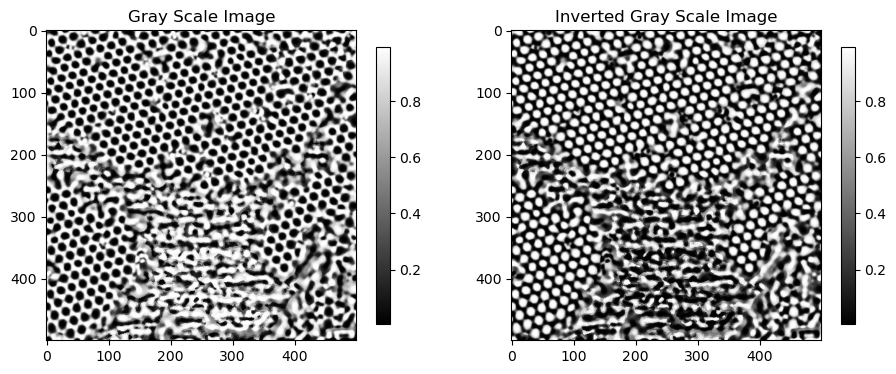

In [953]:
img = img_file(f)
img.load()

img2d = img.img if img.img.ndim == 2 else img.img.mean(axis = 2)
row_means = img2d.mean(axis = 1)
row_devs = np.abs(img2d - row_means[:, None])

max_dev_per_row = row_devs.max(axis = 1)
threshold = max_dev_per_row.mean() + max_dev_per_row.std()
scarred_rows = max_dev_per_row > threshold

mask = np.zeros(img2d.shape, dtype = bool)
mask [scarred_rows, :] = True

inpainted = np.stack([inpaint_biharmonic(img.img[..., c], mask) for c in range(img.img.shape[2])], axis = -1)
source = (inpainted if hasattr(img, 'inpainted') else img.img)
img.img_blurred = filters.gaussian(source, sigma = 3, channel_axis = -1 if source.ndim == 3 else None)
image_gray = np.dot(img.img_blurred[..., :3], [0.2989, 0.5870, 0.1140])
image_norm = (image_gray - image_gray.min()) / (image_gray.max() - image_gray.min())

cmap = cm.get_cmap('afmhot')
colored_image = cmap(image_norm)
img_gr = gray_process(colored_image, dsize = dsize, cutoff = 0.5)

fig, ax = plt.subplots(1, 2, figsize = (11, 6))
im0 = ax[0].imshow(img_gr, cmap = 'gray')
ax[0].set_title('Gray Scale Image')
im1 = ax[1].imshow(util.invert(img_gr), cmap = 'gray')
ax[1].set_title('Inverted Gray Scale Image')

fig.colorbar(im0, ax = ax[0], shrink = 0.6)
fig.colorbar(im1, ax = ax[1], shrink = 0.6)

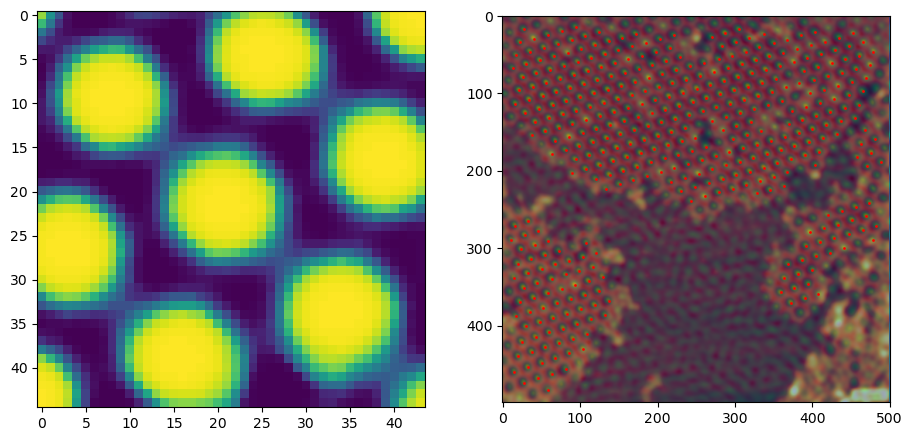

In [954]:
image = 255 - img_gr
img_scale = 53 / img.nm_size
# Used 53 because template came from sample_scale_53.png

im_1 = img_as_float(io.imread("example_temp.png"))
pore = transform.rescale(im_1, scale = img_scale, anti_aliasing = True, channel_axis = -1)
pore = np.dot(pore[..., :3], [0.2989, 0.5870, 0.1140])

border_size = int(pore.shape[0] / 2)
white_value = 255
pad_width = ((border_size, border_size), (border_size, border_size))

bordered = np.pad(image, pad_width = pad_width, mode = 'constant', constant_values = white_value)
result = match_template(bordered, pore, pad_input = False)
peaks = peak_local_max(result, min_distance = 10, threshold_rel = 0.6)

fig, ax = plt.subplots(1, 2, figsize = (11, 6))
im0 = ax[0].imshow(pore)
im1 = ax[1].imshow(result)
ax[1].imshow(colored_image, alpha = 0.5)
plt.plot(peaks[:, 1], peaks[:, 0], 'o', markeredgecolor = 'r', markerfacecolor = 'none', markersize = '1')

In [955]:
graph_node, n = graph_from_peaks(peaks, scale = img.scale, min_dist = 10, area = 1 / img.scale ** 2)

img_vor_t, img_vor_deg_t, v_border, graph_node, graph_inner, p, k_1 = voronoi_tree(img, graph_node, k = 24, power = 0.3)

g_msf = nx.minimum_spanning_tree(graph_inner, weight = 'dis')

Text(0.5, 1.0, 'Voronoi Overlay (Original)')

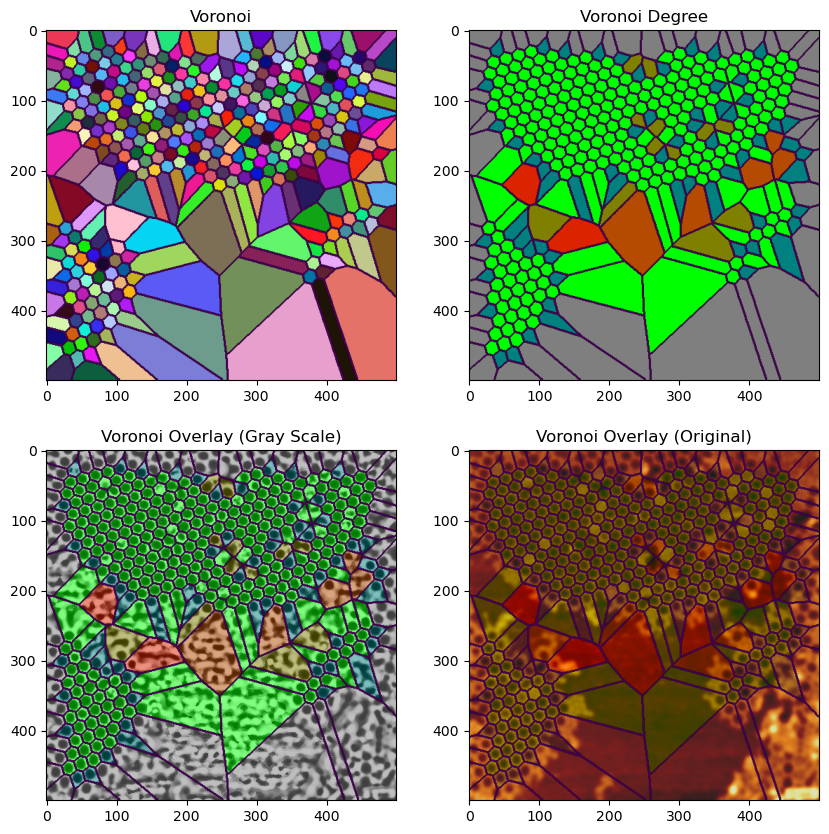

In [956]:
fig, ax = plt.subplots(2, 2, figsize = (10, 10))
ax[0, 0].imshow(img_vor_t)
ax[0, 0].imshow(v_border)
ax[0, 0].set_title('Voronoi')

ax[0, 1].imshow(img_vor_deg_t)
ax[0, 1].imshow(v_border)
ax[0, 1].set_title('Voronoi Degree')

ax[1, 0].imshow(img_gr, cmap = 'gray')
ax[1, 0].imshow(img_vor_deg_t, alpha = 0.5)
ax[1, 0].imshow(v_border)
ax[1, 0].set_title('Voronoi Overlay (Gray Scale)')

ax[1, 1].imshow(colored_image)
ax[1, 1].imshow(img_vor_deg_t, alpha = 0.25)
ax[1, 1].imshow(v_border)
ax[1, 1].set_title('Voronoi Overlay (Original)')

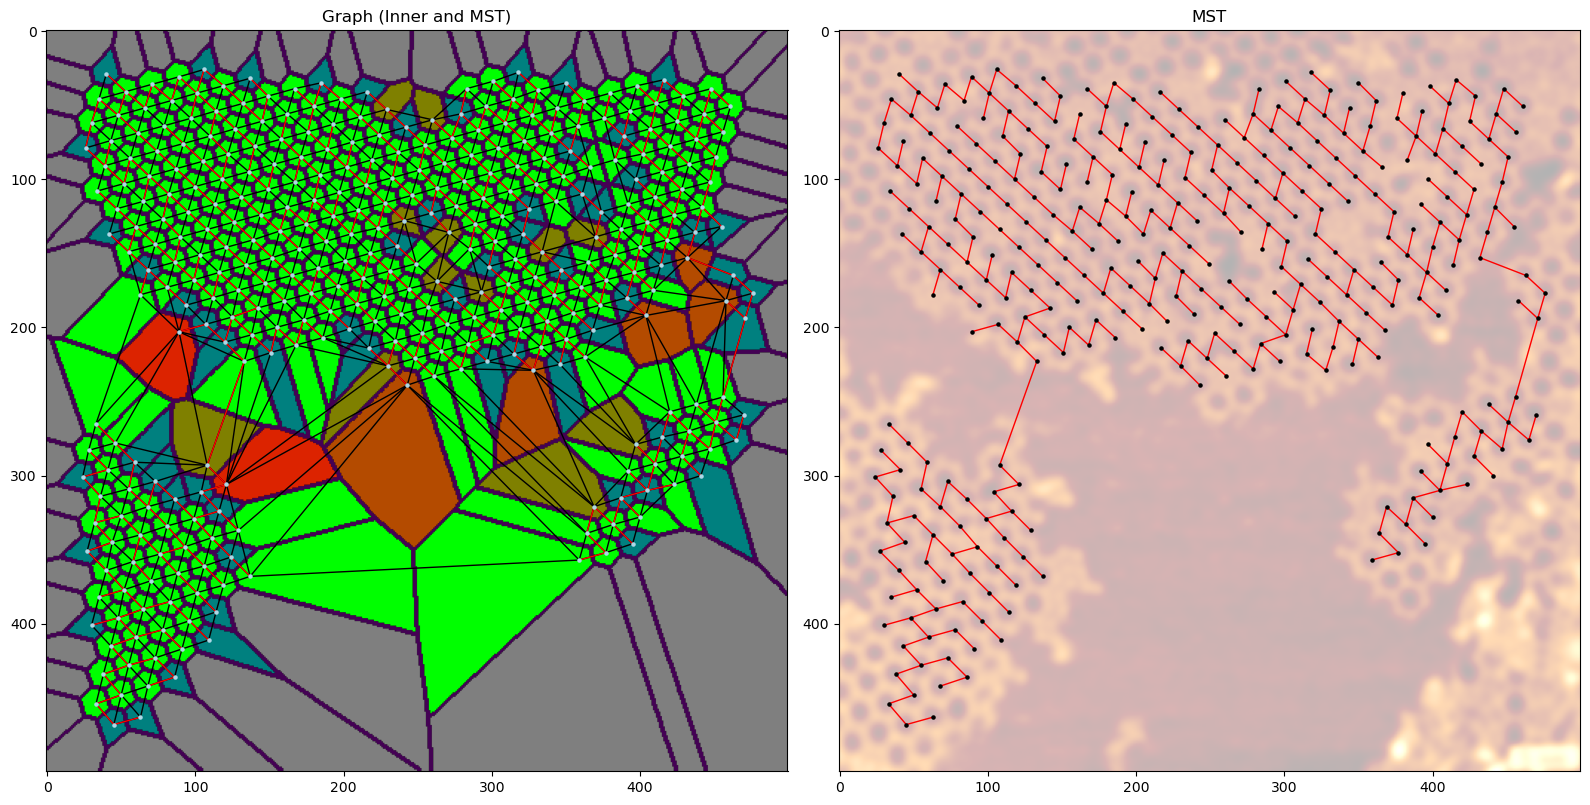

In [963]:
pos = {n:d['pixel_pos'] for n, d in graph_inner.nodes(data = True)}

pos_inner = {node: [dat['pixel_pos'][1], dat['pixel_pos'][0]] for node, dat in graph_inner.nodes(data = True)}
pos_msf = {node: [dat['pixel_pos'][1], dat['pixel_pos'][0]] for node, dat in g_msf.nodes(data = True)}

fig, ax = plt.subplots(1, 2, figsize = (16, 20))

ax[0].imshow(img_vor_deg_t)
ax[0].imshow(v_border)
ax[0].set_title('Graph (Inner and MST)')

xlim = ax[0].get_xlim()
ylim = ax[0].get_ylim()

nx.draw_networkx_nodes(graph_inner, pos_inner, node_color = 'lightblue', node_size = 5, ax = ax[0], hide_ticks = False)
nx.draw_networkx_edges(graph_inner, pos_inner, edge_color = 'black', ax = ax[0], hide_ticks = False)

nx.draw_networkx_edges(g_msf, pos_msf, edge_color = 'red', ax = ax[0], hide_ticks = False)

ax[0].set_xlim(xlim)
ax[0].set_ylim(ylim)

ax[1].imshow(colored_image, alpha = 0.3)
ax[1].set_title('MST')

nx.draw_networkx_nodes(graph_inner, pos_inner, node_color = 'black', node_size = 5, ax = ax[1], hide_ticks = False)
nx.draw_networkx_edges(g_msf, pos_msf, edge_color = 'red', ax = ax[1], hide_ticks = False)

ax[1].set_xlim(xlim)
ax[1].set_ylim(ylim)

plt.tight_layout()
plt.show()

In [958]:
_, _, m, sig, _, defect_ratio = statistics(graph_node, graph_inner, g_msf)
_, _, _, _, G, _, _ = voronoi_tree(img, graph_node, k = k, power = power)

lengths = np.array([G[u][v]['dis'] for u, v in G.edges()])
m_1 = np.mean(lengths)
sig_1 = np.std(lengths)
dsize = (img.scale * m_1 / 2)

print('       --- STATISTICS ---')
print(f'FILE NAME:          {img.name}')
print(f'MEAN EDGE LENGTH:   {m:.6f} (normalized)')
print(f'STANDARD DEVIATION: {sig:.6f} (normalized)')
print(f'MEAN EDGE LENGTH:   {m_1:.6f} nm')
print(f'STANDARD DEVIATION: {sig_1:.6f} nm')
print(f'DEFECT RATIO:       {defect_ratio:.6f}')
print(f'THE VALUE OF DSIZE: {dsize:.6f}')
print('===============================================')
print(f'     ({m:.6f}, {sig:.6f})')

       --- STATISTICS ---
FILE NAME:          sample_scale_53.png
MEAN EDGE LENGTH:   0.827207 (normalized)
STANDARD DEVIATION: 0.171711 (normalized)
MEAN EDGE LENGTH:   2.293456 nm
STANDARD DEVIATION: 1.796781 nm
DEFECT RATIO:       0.233618
THE VALUE OF DSIZE: 10.818190
     (0.827207, 0.171711)
